##**Deep Thinkers Group: Leila Nasimi, Christopher Nichols, Fereshteh Sadeghi Naieni Fard**

**Video Presentation of the Group:** https://youtu.be/p1q71HwOV_Y

**Link to access the Whole Dataset:** https://drive.google.com/drive/folders/1-LSSF_GecaLzGr86RfMHHB-X-kFrY045?usp=sharing

**Research Question**   
How can various deep learning models accurately classify malignant breast cancer histopathology images from benign ones?

**Overview of what we did in this python code page:**
In these code blocks, we tried to develop CNN model with stratified sampling. After defining the trainset and test set by assigning 80 percent of the data to train and 20 percent of the whole data to test set, a convolutional neural network was developed to classify the breast histopathology images into malignant and benign. The input images had three color channels in different sizes that were all transformed into images with height 128 and width 128. All the layers were developed sequentially, and each output is the input of the next layer. It contains two convolutional blocks. In the first convolutional block three of the 2D convolutional layers were used. The layers use 16 filters and create 16 feature maps with 33 kernel and padding equal to 1 to keep the
spatial dimension without any change. Each of those convolutional layers used Tanh activation function that help to identify nonlinear patterns. In the first convolutional layers, the model learns initial features such as lines and edges.
By increasing the layers, the model tried to learn abstract patterns. After three convolutional layers, a Maxpooling layer with kernel size 2 is used to reduce the dimension of feature maps and just keep the important features.
In the second convolutional block, the model used double filters equal to 32, and agin three convolutional layers that used kernel with size 3*3 were applied. Then, the final tensor was flattened into a vector with one dimension.
Because two max pooling was used to reduce the dimension by 4*4=16, the final size of the feature is 2*filters *(D/16) and these features fed into the linear model. After that the model was trained with cross entropy loss function for 20 epochs. The accuracy changes from less than 60 percent in the first epoch to achieve 82.4 percent in the last epoch.
After developing the base model, we tried to increase the accuracy of the model using batch normalization as well as scheduler and optimizer. The result in accuracy reveals more stability in the enhanced model in comparison to the base model. Also, the final accuracy became 86.22 percent.
We then went further and tried to apply various augmentation techniques to examine the performance of the model. Results presented that those augmentation including color changes, rotation, resizing and flipping reduce the diagnostic feature of the images and led to reduced accuracy.
These models help us to gain valuable knowledge about different techniques we could use for improvement of clinical deep learning models for classification.  


# Load Dataset & Import Libraries

In [ ]:
# Import warnings to avoid displaying warning messages
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Download the raw Python file
%%capture
!wget https://raw.githubusercontent.com/EdwardRaff/Inside-Deep-Learning/main/idlmam.py
from idlmam import *

In [ ]:

#The main Pytorch library should be imported to perform deep learning models and  apply tensors
import torch
#The nn module from torch is imported to access to neural network tools such as loss function, and layers
import torch.nn as nn

#All things inside the torch.utils.data module such as Dataset, DataLoader, and random_split are imported to tackle batching and datasets
from torch.utils.data import *

# torchvision which is a PyTorch library is suitable for image transformation and working with images and provides model architectures
import torchvision

# Then the transform module will be imported to apply regular image processing functions such as resizing, normalization, and tensor conversion
#to prepare the images to be feeded into the model
from torchvision import transforms

#Then the datasets module will be imported from torchvision to load images from folder and assign labels to them
from torchvision import datasets

# seaborn is imported to have create beautiful visusalizations of data
import seaborn as sns

# matplotlib's pyplot is imported to generate charts and plots
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.pyplot import imshow

#numpy is imported to allow use arrays, numbers, and math operations
import numpy as np

#Import tqdm for displaying progress bars
from tqdm.autonotebook import tqdm

#Imported accuracy_score metric from scikit-learn to measure the percentage of correct predictions
from sklearn.metrics import accuracy_score

# the transforms module from torchvision is imported for using image processing functions
#It prepares the image data including resize, normalization, and coverting to tensors
from torchvision import transforms

#train_test_split module is imported from sklearn library to split randomly
from sklearn.model_selection import train_test_split

In [ ]:
# get the path of file in the google drive and keep it in the file_path
from google.colab import drive
drive.mount('/content/drive')

file_path="/content/drive/MyDrive/BreaKHis_binary/"

Mounted at /content/drive


In [ ]:
#Here we select the computing device. So, it uses GPU if available, otherwise it will use CPU
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

In [ ]:
#this function controls the randomness and set the random seed for both pyTorch and numpy
def set_seed(seed):
    """
    Set the random seed for reproducibility.
    """
    #Set the random seed for PyTorch
    torch.manual_seed(seed)
    #Set the random seed for numpy
    np.random.seed(seed)
# The GPU use fixed and predictable calculations, and the results will not change each time we run the model.
#It reduces the speed but creates consistent results.
torch.backends.cudnn.deterministic = True
#It uses seed 42 as the starting point for all generated random numbers
set_seed(42)


# A. Fereshteh Sadeghi Naieni Fard
Max Pooling   

In this part, the base model following the course topic was developed to address the research question. Then, images resized to 128*128 and dataset split using stratified random sampling. Then, three convolutional layer neural network developed, and its accuracy measured after training for 20 epochs.

In [ ]:
# Load the breast histophatological images from the folder in google drive and then resize all to 128*128 and convert those images to tensors
dataset = torchvision.datasets.ImageFolder(
    file_path,
    transform=transforms.Compose([
        transforms.Resize((128,128)),
        transforms.ToTensor()
    ])
)

In [ ]:

# Reference: https://stackoverflow.com/questions/73097705/stratified-train-val-test-split-in-pytorch
# This code block performs stratified sampling using train test split from sklearm
#First, it devides the indexes of the dataset into two categories and this range(len(dataset)) generates a list of index numbers and it means that the splitting is done uisng the labels of samples
#so by applying test_size=0.2, 20 percent of the data were assigned to test set and 80 percent to train set.
#Also, by uisng stratify=dataset.targets the distribution of the classes were kept in train and test sets.
#It means that if we have 60 percent for malignamt and 40 percent for benign the train and test sets have also the same proportion.
#Finally by using subset and the labels of the images create a dataset for each train and test sets
#This code applies stratified splitting to solve the problem of calss imbalance.

train_indicesFSNF, test_indicesFSNF = train_test_split(
    range(len(dataset)),
    stratify=dataset.targets,
    test_size=0.2,
    random_state=42
)

train_dataset = Subset(dataset, train_indicesFSNF)
test_dataset  = Subset(dataset, test_indicesFSNF)

In [ ]:
#Using dataloader to have a batch of size 32 for preprocessing each time and shuffle the training set to order them randomly in each epoch
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

#Uisng dataloader to have also a batch of size 32 for preprocessing each time but do not shuffle to create consistent results
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)


In [ ]:
#In this code block, a convolutional neural network with three layers were genrated
#It contains three convolutional layers with 16 filters that are followed by a MaxPool2d layer
# And after that again three convolutional layers with 32 filters were developed and followed by MaxPool2d
# These max pooling perform key role in reducing the dimensions of the images.
#Accordingly the model will learn just important features
#B is the batchsize that shows 32 images will be processed each time
# C is the number of channels and since the histopathological images has colors, It was set to 3
# W and H are the width and height of the image and  they were rezised to 128*128
# D is introduced as the whole number of features and it is equal to 128 * 128 = 16384

B = 32
C = 3
W = 128
H = 128
D = W * H

# classes will be set to 2 and shows the number of classes for classification (malignant and benign)
classes = 2

# 16 filters were utilized to learn various spatial patterns of the images
filters = 16

# k present the kernel size or the size of each convoloutional filter
K = 3

# Here we created the architecture of the model using nn.sequential
model_cnn_pool = nn.Sequential(

#2D convoloutonal layers created to operate over 2 spatial dimensions (height and width)
#that uses kernels to image data. the first arguemnt is number of input channels c=3, and
#the number of output channels that are equal to the number of filters=16 and each filter find different features including edges, shapes, or textures
#The third argument is the size of kernel equal to 3. It means that  a matrix of 3*3 is used to slide over the images to find patterns
#The next argument is padding that is equal to 1 which adds one zero layer to the border of the images to keep spatial size unchanged and creating feature maps with unchanged sizes
#The first convoloutional layer often discover simple features such as lines or edges, but the second layer try to find more meaning patterns by combining those edges and lines
#In the third convoloutional layer the model tries to use and combine early detected features to identify abstract patterns like part of the object

# So the first convoloutional layer is applied on 3 channel images.
  nn.Conv2d(C, filters, 3, padding=3//2),

#Then Tanh activation function was applied to capture nonlinear patterns
  nn.Tanh(),

 # The second convoloutional layer is created to process the outputs of the first one
  #again with using Tanh activation function
  nn.Conv2d(filters, filters, 3, padding=3//2),
  nn.Tanh(),


  # The third convoloutional layer was generated to find abstract patterns
  # again with using tanh activation function to capture nonlinear patterns
  nn.Conv2d(filters, filters, 3, padding=3//2),
  nn.Tanh(),

  # Then, MaxPooling is used to reduces the height and width of the feature maps by factor of 2
  nn.MaxPool2d(2),

  # here the Second convolution block were applied using 32 filters (16*2) to stride over images for identifying more patterns
  nn.Conv2d(filters, 2*filters, 3, padding=3//2),
  nn.Tanh(),

  nn.Conv2d(2*filters, 2*filters, 3, padding=3//2),
  nn.Tanh(),

  nn.Conv2d(2*filters, 2*filters, 3, padding=3//2),
  nn.Tanh(),

  # Then, second MaxPooling is used to reduces the height and width of the feature maps by factor of 2
  nn.MaxPool2d(2),

  # Finally the output is flatten to create a vector for feeding to the dense layer
  nn.Flatten(),

  # We used 2*2 maxpooling. So, the spatial dimensions were reduced by 4*4=16
  # So the final input for the linear layer is 2*filters*(D/16)=2*16*(12*128)/16=32768
  nn.Linear(2*filters*D//(4**2), classes),
)

#Using cross entropy as the loss function
loss_func = nn.CrossEntropyLoss()


#Then using the function train_network() that includes forward pass, backpropagation,
# loss computation, updating weights, and finally calculating the accuracy. This function used
#20 epoches to train the CNN model and strore the accuracy of all epochs
cnn_results_with_pool = train_network(
    model_cnn_pool,
    loss_func,
    train_loader,
    test_loader=test_loader,
    score_funcs={'Accuracy': accuracy_score},
    device=device,
    epochs=20
)

<Axes: xlabel='epoch', ylabel='test Accuracy'>

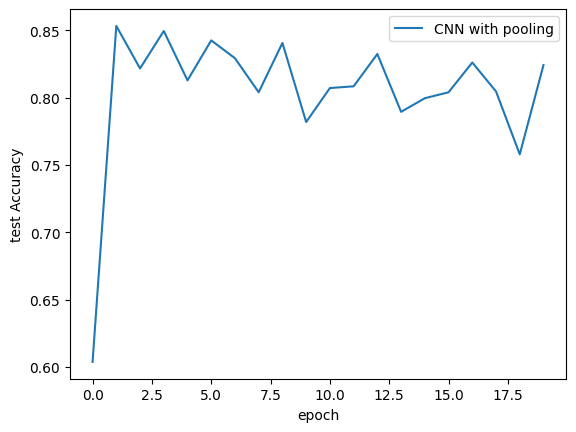

In [ ]:
# Then, the line graph which shows the changes of test accuracy over training epochs for simple CNN with maxpooling and startified sampling is created
# The result presented that the accuracy on the first epoch started from 0.60 and then increased and reached to 0.82.4 at the 20th epoch.
# After fluctionations between 0.60 and 0.85, the test accuracy achieved 0.82.4 on the 20th epoch.
sns.lineplot(x='epoch', y='test Accuracy', data=cnn_results_with_pool, label='CNN with pooling')


# B. Chris Nichols
Batch Normalization + Optimizer + Scheduler

In this part, the base model was enhanced using batch normalization, exponential Lr, and Adam optimizer to introduce better accuracy and stability.

In [ ]:
#In this code block, a convolutional neural network with three layers were generated
#After the Convolution layers, we then added batch normalization layers followed
#by hyperbolic tangent activation functions.
#The first three convolutional layers contain 16 filters that are followed by a MaxPool2d layer
# And after that again three convolutional layers were developed using
#batch normalization with tanh() and followed by MaxPool2d
# These max pooling perform key role in reducing the dimensions of the images.
#Accordingly the model will learn just important features

#B is the batchsize that shows 32 images will be processed each time
# C is the number of channels and since the histopathological images has colors, It was set to 3
# W and H are the width and height of the image and  they were rezised to 128*128
# D is introduced as the whole number of features and it is equal to 128 * 128 = 16384

B = 32
C = 3
W = 128
H = 128
D = W * H

# classes will be set to 2 and shows the number of classes for classification (malignant and benign)
classes = 2

# 16 filters were utilized to learn various spatial patterns of the images
filters = 16

# k present the kernel size or the size of each convoloutional filter
K = 3

# here we created the architecture of the model using nn.sequential
model_cnn_pool_batch_normalized = nn.Sequential(

#The first three convolution layers include batch normalization
#Tanh() activations functions deployed
#Filters set at 16 are inputted with 3/2 padding as well

# So the first convoloutional layer is applied on 3 channel images.
  nn.Conv2d(C, filters, 3, padding=3//2),

 nn.BatchNorm2d(filters), #batch normalization layers added with filters inputted

  #then Tanh activation function was applied to capture nonlinear patterns
  nn.Tanh(),

  # The second convoloutional layer is created to process the outputs of the first one
  #again with using Tanh activation function
  nn.Conv2d(filters, filters, 3, padding=3//2),
  nn.BatchNorm2d(filters),  #batch normalization layers added with filters inputted
  nn.Tanh(),


  # The third convoloutional layer was generated to find abstract patterns
  # again with using tanh activation function to capture nonlinear patterns
  nn.Conv2d(filters, filters, 3, padding=3//2),
  nn.BatchNorm2d(filters),   #batch normalization layers added with filters inputted
  nn.Tanh(),

  # Then, MaxPooling is used to reduces the height and width of the feature maps by factor of 2
  nn.MaxPool2d(2),

  #a block of three convolution layers with batch normalization were applied using 32 filters (16*2)
  #to stride over images for identifying more possible patterns. Again tanh() activations with padding
  # set to 1

  nn.Conv2d(filters, 2*filters, 3, padding=3//2),
   nn.BatchNorm2d(2*filters),   #batch normalization layers added with filters inputted
  nn.Tanh(),

  nn.Conv2d(2*filters, 2*filters, 3, padding=3//2),
   nn.BatchNorm2d(2*filters),   #batch normalization layers added with filters inputted
  nn.Tanh(),

  nn.Conv2d(2*filters, 2*filters, 3, padding=3//2),
   nn.BatchNorm2d(2*filters),   #batch normalization layers added with filters inputted
  nn.Tanh(),

  # Then, second MaxPooling is used to reduces the height and width of the feature maps by factor of 2
  nn.MaxPool2d(2),

  # Finally the output is flatten to create a vector for feeding to the dense layer
  nn.Flatten(),

  # We used 2*2 maxpooling. So, the spatial dimensions were reduced by 4*4=16
  # So the final input for the linear layer is 2*filters*(D/16)=2*16*(12*128)/16=32768
  nn.Linear(2*filters*D//(4**2), classes),
)

#Using cross entropy as the loss function
loss_func = nn.CrossEntropyLoss()

#optimizer with learning rate of 0.001
optimizer = torch.optim.Adam(model_cnn_pool.parameters(), lr=0.001)

#exponential lr schedule with gamma of 0.9
scheduler = torch.optim.lr_scheduler.ExponentialLR(
    optimizer,
    gamma=0.9
)



#declare optimizer varible using Adam and basic_cnn parameters with a learning
#rate of 0.001)
optimizer = torch.optim.Adam(model_cnn_pool_batch_normalized.parameters(), lr = 0.001)

#adding exponential learning rate scheduler; gamma = (0.0001/0.001)**(1/20)
lr_schedule = torch.optim.lr_scheduler.ExponentialLR(optimizer,  gamma= 0.8912)

#Using the function train_network() that includes the optimizer and lr schedule. This function used
#20 epoches to train the CNN model and strore the accuracy of all epochs
cnn_results_normalized_exponetial_optimized = train_network(
    model_cnn_pool_batch_normalized,
    loss_func,
    train_loader,
    test_loader=test_loader,
    score_funcs={'Accuracy': accuracy_score},
    device=device,
    optimizer=optimizer,
    lr_schedule=lr_schedule,
    epochs=20
)

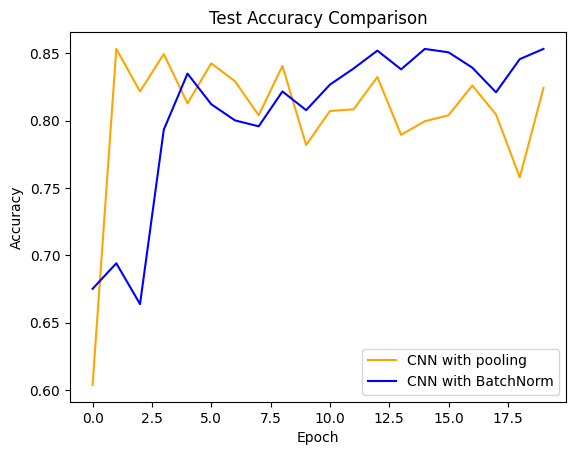

In [ ]:
# Then, the line graph which compares the accuracies of the original and batchnorm model with optimizer and exponential lr
# The new model presented that the accuracy on the first epoch started from 0.67 and then increased and reached to 86.22 at the 20th epoch.
# The final accuracy achieved was noticably hire than our first model

plt.figure()

sns.lineplot(
    x='epoch',
    y='test Accuracy',
    data=cnn_results_with_pool,
    label='CNN with pooling',
    color='orange'
)

sns.lineplot(
    x='epoch',
    y='test Accuracy',
    data=cnn_results_normalized_exponetial_optimized,
    label='CNN with BatchNorm',
    color='blue'
)

plt.title("Test Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# C. Leila Nasimi
Augmentation + Optimizer + Scheduler

This part improves the CNN by adding image augmentation during training. The histopathology images are loaded from Google Drive, resized to 128×128, and converted to RGB tensors. The dataset is split into train and test using stratified sampling, so both sets keep the same benign/malignant balance.

For the training set only, extra random changes are applied to the images (random crop, left/right and up/down flips, small rotate/shift/zoom, slight warp, and small color changes). This helps the model see more variety of the same patterns and reduces overfitting. The test set is not changed, so the accuracy shows the real performance on clean data.

In [ ]:
# Load the beast histophatological images from the folder in google drive and then resize all to 128*128 and convert those images to tensors
dataset = torchvision.datasets.ImageFolder(   # Load dataset
    file_path,
    transform=transforms.Compose([            # Apply transforms to each image
        transforms.Resize((128,128)),         # Resize
        transforms.ToTensor()                 # Convert images to tensor
    ])
)

In [ ]:
# Define train transforms (with augmentation)
train_transform_aug = transforms.Compose([
    transforms.Resize((128 + 12, 128 + 12)),           # Resize (slight upsize)
    transforms.Lambda(lambda img: img.convert("RGB")), # Force RGB

    transforms.RandomCrop((128, 128)),                 # Crop to 128x128
    transforms.RandomHorizontalFlip(p=0.5),            # Horizontal flip
    transforms.RandomVerticalFlip(p=0.3),              # Vertical flip

    transforms.RandomAffine(                           # Small random changes
        degrees=15,                                    # rotate, shift, scale
        translate=(0.05, 0.05),
        scale=(0.95, 1.05),
        shear=8
    ),

    transforms.RandomPerspective(distortion_scale=0.15, p=0.3),  # Slight warp

    transforms.ColorJitter(       # Slight color changes
        brightness=0.15,
        contrast=0.15,
        saturation=0.15
    ),

    transforms.ToTensor(),       # Convert to tensor

    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],    # Normalize
        std=[0.5, 0.5, 0.5]
    ),
])

# Define test transforms (NO augmentation)
test_transform = transforms.Compose([
    transforms.Resize((128, 128)),                      # Resize
    transforms.Lambda(lambda img: img.convert("RGB")),  # Force RGB

    transforms.ToTensor(),      # Convert to tensor

    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],   # Normalize
        std=[0.5, 0.5, 0.5]
    ),
])


In [ ]:
# Load Full Dataset WITHOUT transform
dataset = torchvision.datasets.ImageFolder(file_path)

In [ ]:

# Reference: https://stackoverflow.com/questions/73097705/stratified-train-val-test-split-in-pytorch
# This code block performs stratified sampling using train test split from sklearm
#First, it devides the indexes of the dataset into two categories and this range(len(dataset)) generates a list of index numbers and it means that the splitting is done uisng the labels of samples
#so by applying test_size=0.2, 20 percent of the data were assigned to test set and 80 percent to train set.
#Also, by uisng stratify=dataset.targets the distribution of the classes were kept in train and test sets.
#It means that if we have 60 percent for malignamt and 40 percent for benign the train and test sets have also the same proportion.
#Finally by using subset and the labels of the images create a datset for each train and test sets
#This code applies stratified splitting to solve the problem of calss imbalance.

train_indices, test_indices = train_test_split( # Split images into train/test
    range(len(dataset)),                        # Use all images
    stratify=dataset.targets,                   # Keep class balance (stratify)
    test_size=0.2,                              # 20% for testing
    random_state=42                             # Reproducible split
)

train_dataset = Subset(dataset, train_indices)  # Train subset
test_dataset  = Subset(dataset, test_indices)   # Test subset

# Assign Transforms AFTER splitting
train_dataset.dataset.transform = train_transform_aug # Augment train only
test_dataset.dataset.transform  = test_transform      # No aug on test

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True) # Train (shuffle)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False) # Test (NO shuffle)

In [ ]:
#In this code block, a convolutional neural network with three layers were genrated
#It contains three convolutional layers that are followed by a MaxPool2d layer
# And after that again three convolutional layers were developed and followed by MaxPool2d
# These max pooling perform key role in reducing the dimensions of the images.
#Accordingly the model will learn just important features
#B is the batchsize that shows 32 images will be processed each time
# C is the number of channels and since the histopathological images has colors, It was set to 3
# W and H are the width and height of the image and  they were rezised to 128*128
# D is introduced as the whole number of features and it is equal to 128 * 128 = 16384

B = 32
C = 3
W = 128
H = 128
D = W * H

# classes will be set to 2 and shows the number of classes for classification (malignant and benign)
classes = 2

# 16 filters were utilized to learn various spatial patterns of the images
filters = 16

# k present the kernel size or the size of each convoloutional filter
K = 3

# here we created the architecture of the model using nn.sequential
model_cnn_pool_batch_normalized_augmented = nn.Sequential(

#2D convoloutonal layers are created to operate over 2 spatial dimensions (height and width)
#that uses kernels to image data. the first arguemnt is number of input channels c=3, and
#the number of output channels that are equal to the number of filters=16 and each filter find different features including edges, shapes, or textures
#The third argument is the size of kernel equal to 3. It means that  a matrix of 3*3 is used to slide over the images to find patterns
#The next argument is padding that is equal to 1 which adds one zero layer to the border of the images to keep spatial size unchanged and creating feature maps with unchanged sizes
#The first convoloutional layer often discover simple features such as lines or edges, but the second layer try to find more meaning patterns by combining those edges and lines
#In the third convoloutional layer the model tries to use and combine early detected features to identify abstract patterns like part of the object

# So the first convoloutional layer is applied on 3 channel images.
  nn.Conv2d(C, filters, 3, padding=3//2),

 nn.BatchNorm2d(filters),

  #then Tanh activation function was applied to capture nonlinear patterns
  nn.Tanh(),

  # The second convoloutional layer is created to process the outputs of the first one
  #again with using Tanh activation function
  nn.Conv2d(filters, filters, 3, padding=3//2),
  nn.BatchNorm2d(filters),
  nn.Tanh(),


  # The third convoloutional layer was generated to find abstract patterns
  # again with using tanh activation function to capture nonlinear patterns
  nn.Conv2d(filters, filters, 3, padding=3//2),

  nn.BatchNorm2d(filters),
  nn.Tanh(),

  # Then, MaxPooling is used to reduces the height and width of the feature maps by factor of 2
  nn.MaxPool2d(2),

  # here the Second convolution block were applied using 32 filters (16*2) to stride over images for identifying more patterns
  nn.Conv2d(filters, 2*filters, 3, padding=3//2),
   nn.BatchNorm2d(2*filters),
  nn.Tanh(),

  nn.Conv2d(2*filters, 2*filters, 3, padding=3//2),
   nn.BatchNorm2d(2*filters),
  nn.Tanh(),

  nn.Conv2d(2*filters, 2*filters, 3, padding=3//2),
   nn.BatchNorm2d(2*filters),
  nn.Tanh(),

  # Then, second MaxPooling is used to reduces the height and width of the feature maps by factor of 2
  nn.MaxPool2d(2),

  # Finally the output is flatten to create a vector for feeding to the dense layer
  nn.Flatten(),

  # We used 2*2 maxpooling. So, the spatial dimensions were reduced by 4*4=16
  # So the final input for the linear layer is 2*filters*(D/16)=2*16*(12*128)/16=32768
  nn.Linear(2*filters*D//(4**2), classes),
)

#Using cross entropy as the loss function
loss_func = nn.CrossEntropyLoss()


optimizer = torch.optim.Adam(model_cnn_pool.parameters(), lr=0.001)

scheduler = torch.optim.lr_scheduler.ExponentialLR(
    optimizer,
    gamma=0.9
)

#declare optimizer varible using Adam and basic_cnn parameters with a learning
#rate of 0.001)
optimizer = torch.optim.Adam(model_cnn_pool_batch_normalized.parameters(), lr = 0.001)

#adding exponential learning rate scheduler; gamma = (0.0001/0.001)**(1/20)
lr_schedule = torch.optim.lr_scheduler.ExponentialLR(optimizer,  gamma= 0.8912)

#Then using the function train_network() that includes forward pass, backpropagation,
# loss computation, updating weights, and finally calculating the accuracy. This function used
#20 epoches to train the CNN model and strore the accuracy of all epochs
cnn_results_normalized_exponetial_optimized_augmented = train_network(
    model_cnn_pool_batch_normalized_augmented,# CNN model
    loss_func,                                # Loss function
    train_loader,                             # Train data (with aug)
    test_loader=test_loader,                  # Test data (no aug)
    score_funcs={'Accuracy': accuracy_score}, # Track accuracy
    device=device,                            # GPU/CPU
    optimizer=optimizer,                      # Adam
    lr_schedule=lr_schedule,                  # Exponential Learning Rate
    epochs=20
)

# Compare Results

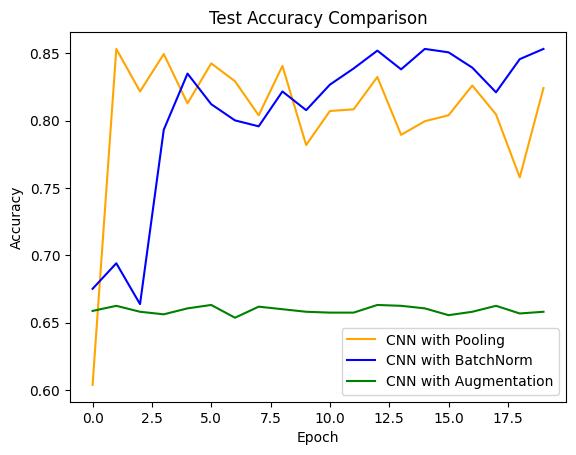

In [ ]:
# Then, the line graph which compares the accuracies of the original and batchnorm model with optimizer and exponential_Lr and augmented model with optimizer and exponential lr
# The new augmented model presented that the accuracy is stable around 0.67 across all 20 epochs.
# This result shows augmentation reduce the diagnostic characteristics of breast histopathological images
# The best model is batchnormalized model with optimizer and scheduler

plt.figure()

sns.lineplot(
    x='epoch',
    y='test Accuracy',
    data=cnn_results_with_pool,
    label='CNN with Pooling',
    color='orange'
)

sns.lineplot(
    x='epoch',
    y='test Accuracy',
    data=cnn_results_normalized_exponetial_optimized,
    label='CNN with BatchNorm',
    color='blue'
)

sns.lineplot(
    x='epoch',
    y='test Accuracy',
    data=cnn_results_normalized_exponetial_optimized_augmented,
    label='CNN with Augmentation',
    color='green'
)




plt.title("Test Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [ ]:
#Print the accuracy of each model in the 20th epoch
print("Model 1: CNN + Max Pooling")
print("Optimizer: --")
print("Scheduler: --")
print(f"Final Test Accuracy: {cnn_results_with_pool['test Accuracy'].iloc[-1]*100:.2f}%")

print("\nModel 2: CNN + Batch Normalization")
print("Optimizer: Adam")
print("Scheduler: Exponential LR")
print(f"Final Test Accuracy: {cnn_results_normalized_exponetial_optimized['test Accuracy'].iloc[-1]*100:.2f}%")

print("\nModel 3: CNN + Augmentation")
print("Optimizer: Adam")
print("Scheduler: Exponential LR")
print(f"Final Test Accuracy: {cnn_results_normalized_exponetial_optimized_augmented['test Accuracy'].iloc[-1]*100:.2f}%")


Model 1: CNN + Max Pooling
Optimizer: --
Scheduler: --
Final Test Accuracy: 82.43%

Model 2: CNN + Batch Normalization
Optimizer: Adam
Scheduler: Exponential LR
Final Test Accuracy: 85.34%

Model 3: CNN + Augmentation
Optimizer: Adam
Scheduler: Exponential LR
Final Test Accuracy: 65.80%
